In [1]:
import pandas as pd
from geographiclib.geodesic import Geodesic
import geopandas
import math
import folium
from shapely.geometry import Point
from shapely.geometry import Polygon
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('clean_navcen_obc_datav2.csv')
mid_df = pd.read_csv('mid_datav2.csv')
gold_df = pd.read_csv('golden_datasetv4.csv')

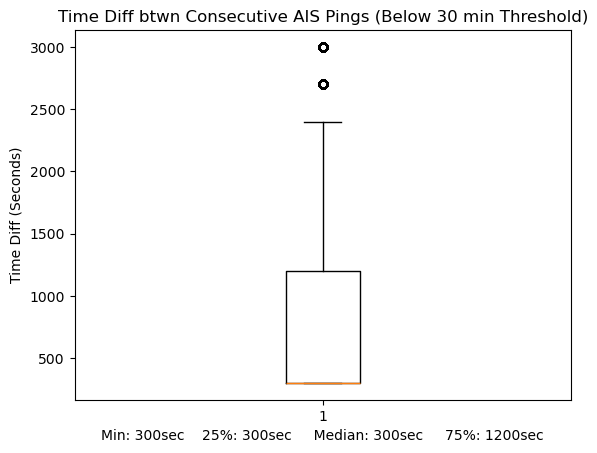

In [4]:
time_diff = list(df['time_diff'])
time_diff_norm = [time for time in time_diff if time <= 3000]
time_diff_out = [time for time in time_diff if time > 3000]
percent = len(time_diff_norm) / (len(time_diff_out) + len(time_diff_norm))
over_day = [time for time in time_diff_out if time > 86400]

plt.boxplot(time_diff_norm)
plt.ylabel('Time Diff (Seconds)')
plt.title('Time Diff btwn Consecutive AIS Pings (Below 30 min Threshold)')
plt.xlabel('Min: 300sec    25%: 300sec     Median: 300sec     75%: 1200sec')
plt.show()

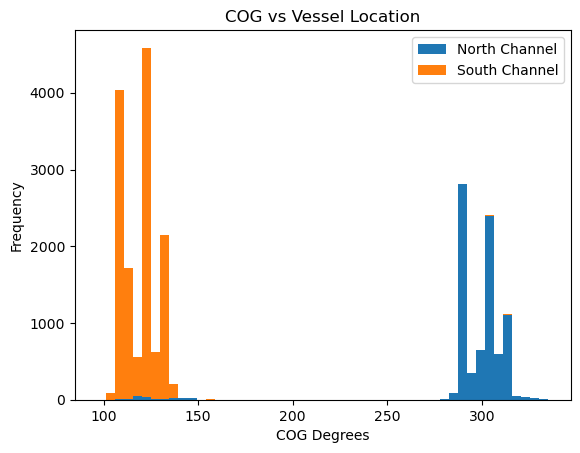

In [8]:
import matplotlib.pyplot as plt
df1 = mid_df[(mid_df['in_channel_north']==True) | (mid_df['location'] == 'north')]
df2 = mid_df[(mid_df['in_channel_south']==True) | (mid_df['location'] == 'south')]


list1 = list(df1['COG_DEG'])
list2 = list(df2['COG_DEG'])
plt.hist([list1, list2], 50, histtype='bar', stacked=True, label = ['North Channel', 'South Channel'])
plt.xlabel('COG Degrees')
plt.ylabel('Frequency')
plt.legend()
plt.title('COG vs Vessel Location')
plt.show()

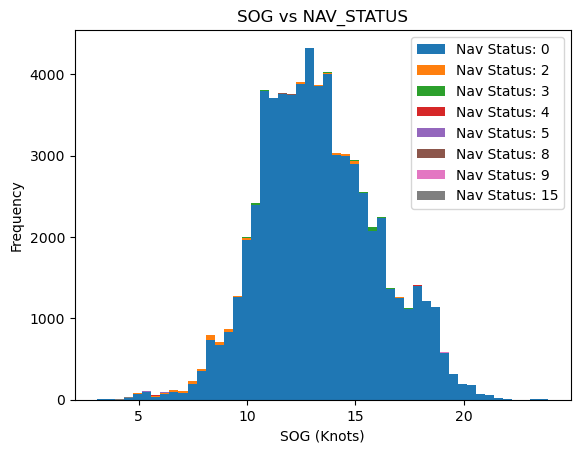

In [5]:
import matplotlib.pyplot as plt
df0 = mid_df[mid_df['NAV_STATUS'] == 0]
df8 = mid_df[mid_df['NAV_STATUS'] == 8]
df5 = mid_df[mid_df['NAV_STATUS'] == 5]
df2 = mid_df[mid_df['NAV_STATUS'] == 2]
df3 = mid_df[mid_df['NAV_STATUS'] == 3]
df4 = mid_df[mid_df['NAV_STATUS'] == 4]
df15 = mid_df[mid_df['NAV_STATUS'] == 15]
df9 = mid_df[mid_df['NAV_STATUS'] == 9]

list0 = list(df0['SPEED_KNOTS'])
list8 = list(df8['SPEED_KNOTS'])
list5 = list(df5['SPEED_KNOTS'])
list2 = list(df2['SPEED_KNOTS'])
list3 = list(df3['SPEED_KNOTS'])
list4 = list(df4['SPEED_KNOTS'])
list15 = list(df15['SPEED_KNOTS'])
list9 = list(df9['SPEED_KNOTS'])

label_list = ['Nav Status:' + ' ' + str(num) for num in [0,2,3,4,5,8,9,15]]
plt.hist([list0, list8, list5, list2, list3, list4, list15, list9], 50, histtype='bar', stacked=True, label = label_list) #add label
plt.xlabel('SOG (Knots)')
plt.ylabel('Frequency')
plt.legend()
plt.title('SOG vs NAV_STATUS')
plt.show()

/tmp/ipykernel_38914/3999311636.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


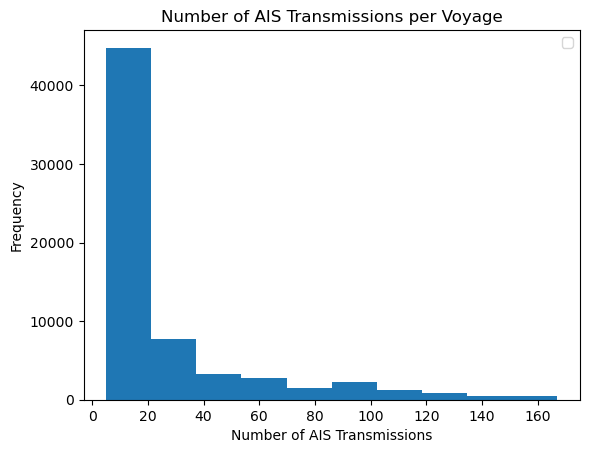

In [26]:
plt.hist(mid_df['num_pings'])
plt.xlabel('Number of AIS Transmissions')
plt.ylabel('Frequency')
plt.legend()
plt.title('Number of AIS Transmissions per Voyage')
plt.show()

/tmp/ipykernel_38914/376080943.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


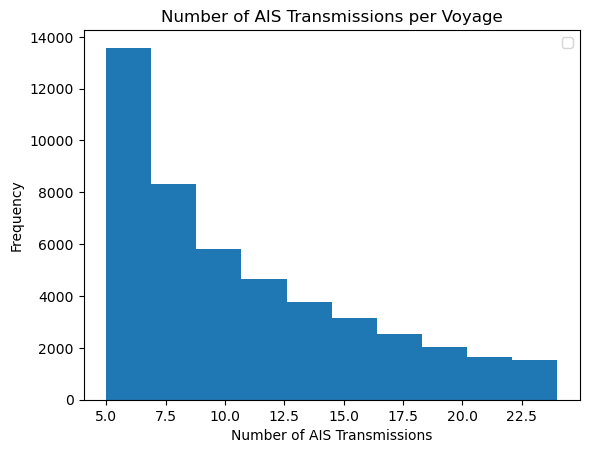

In [28]:
small_df = mid_df[mid_df['num_pings'] < 25]
plt.hist(small_df['num_pings'])
plt.xlabel('Number of AIS Transmissions')
plt.ylabel('Frequency')
plt.legend()
plt.title('Number of AIS Transmissions per Voyage Truncated')
plt.show()

In [31]:
mid_df['sin_cog'] = df['COG_DEG'].apply(lambda x: np.sin(np.radians(x)))
mid_df['cos_cog'] = df['COG_DEG'].apply(lambda x: np.cos(np.radians(x)))
mid_df['sin_heading'] = df['HEADING_DEG'].apply(lambda x: np.sin(np.radians(x)))
mid_df['cos_heading'] = df['HEADING_DEG'].apply(lambda x: np.cos(np.radians(x)))

In [37]:
mid_df.columns
mid_df['beam'] = mid_df['BEAM']
mid_df['length'] = mid_df['LENGTH']
features_df = mid_df[['in_channel_north',
       'in_channel_south','location',
       'num_pings', 'sin_cog', 'cos_cog', 'sin_heading', 'cos_heading']]
features_df.head(10)

,in_channel_north,in_channel_south,location,num_pings,sin_cog,cos_cog,sin_heading,cos_heading
0,False,True,in south channel,5,0.939693,-0.342020,0.933580,-0.358368
1,False,True,in south channel,5,0.932324,-0.361625,0.927184,-0.374607
2,False,True,in south channel,5,0.931691,-0.363251,0.927184,-0.374607
3,False,True,in south channel,5,0.937282,-0.348572,0.933580,-0.358368
4,False,True,in south channel,5,0.938493,-0.345298,0.933580,-0.358368
5,False,False,east,7,0.931691,-0.363251,0.927184,-0.374607
6,False,False,east,7,0.860742,-0.509041,0.838671,-0.544639
7,False,False,east,7,0.772734,-0.634731,0.766044,-0.642788
8,False,False,east,7,0.768284,-0.640110,0.766044,-0.642788
9,False,False,east,7,0.833886,-0.551937,0.829038,-0.559193


In [39]:
mid_df[['beam', 'length', 'channel_side', 'time_diff',
       'new_voyage', 'voyage_id', 'geometry']].head(10)

,beam,length,channel_side,time_diff,new_voyage,voyage_id,geometry
0,60,336,Southeastbound,NaN,True,1_205042000,POINT (-78.616947 22.736758)
1,60,336,Southeastbound,1200.0,False,1_205042000,POINT (-78.53628 22.707576)
2,60,336,Southeastbound,300.0,False,1_205042000,POINT (-78.53135 22.705818)
3,60,336,Southeastbound,1800.0,False,1_205042000,POINT (-78.419349 22.66679)
4,60,336,Southeastbound,600.0,False,1_205042000,POINT (-78.384704 22.654898)
5,60,336,Southeastbound,3300.0,True,4_205042000,POINT (-77.415842 22.102405)
6,60,336,Southeastbound,1200.0,False,4_205042000,POINT (-77.354941 22.057641)
7,60,336,Southeastbound,300.0,False,4_205042000,POINT (-77.348124 22.052238)
8,60,336,Southeastbound,300.0,False,4_205042000,POINT (-77.320791 22.030607)
9,60,336,Southeastbound,1500.0,False,4_205042000,POINT (-77.237966 21.995985)


In [3]:
bound = pd.read_csv('obc_boundaries.csv')
bound['geometry'] = bound.apply(lambda x: (float(x.Long), float(x.Lat)), axis=1)
channel_coords = list(bound['geometry'])
channel_coords_north = [channel_coords[0], channel_coords[1], channel_coords[2], channel_coords[3], channel_coords[-1], channel_coords[-2], channel_coords[-3], channel_coords[-4]]
channel_coords_south = [channel_coords[4], channel_coords[5], channel_coords[6], channel_coords[7], channel_coords[-1], channel_coords[-2], channel_coords[-3], channel_coords[-4]]
coords_north = [channel_coords[0], channel_coords[1], channel_coords[2], (-77.44235, 22.18378333), (-77.44235, 23.80836667), (-78.72296667, 23.80836667)]
coords_south = [channel_coords[4], channel_coords[5], channel_coords[6], channel_coords[7], (-77.4681,21.15348333), (-78.75143333, 21.15348333)]
channel_polygon_n = Polygon(channel_coords_north)
channel_polygon_s = Polygon(channel_coords_south)
polygon_n = Polygon(coords_north)
polygon_s = Polygon(coords_south)

my_map = folium.Map(location=[22.5, -77.8], zoom_start=9.45)
folium.GeoJson(channel_polygon_s, color='green').add_to(my_map)
folium.GeoJson(channel_polygon_n, color='orange').add_to(my_map)

In [7]:
df = pd.read_csv("mid_datav4.csv")

def plot_sample(df, percent=0.1, seed=None):
    """
    Plot a random percentage of lat/lon points on a Folium map.

    Args:
        df (DataFrame): Must contain 'lat' and 'lon' columns
        percent (float): Fraction to sample (e.g., 0.1 = 10%)
        seed (int): Random seed for reproducibility
    """

    # Sample the dataframe
    sample_df = df.sample(frac=percent, random_state=seed)

    # Add points
    for _, row in sample_df.iterrows():
        folium.CircleMarker(
            location=[row['LAT_AVG'], row['LON_AVG']],
            radius=2,
            color='blue',
            fill=True,
            fill_opacity=0.6
        ).add_to(my_map)


In [8]:
my_map